In [138]:
! pip install seaborn

In [139]:
import pandas as pd
import numpy as np

df = pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [141]:
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [142]:
df.isnull().sum().sort_values(ascending=False)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

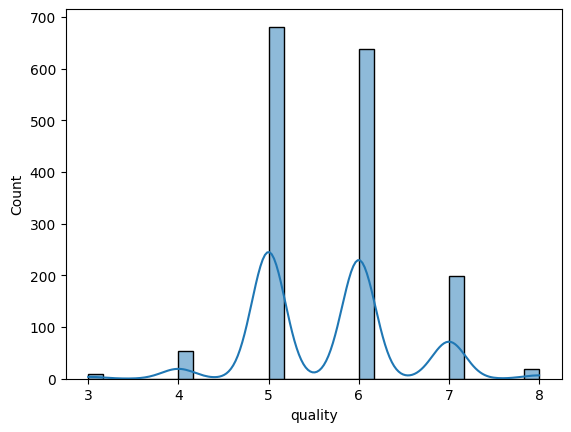

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.histplot(df["quality"], kde=True)
plt.show()

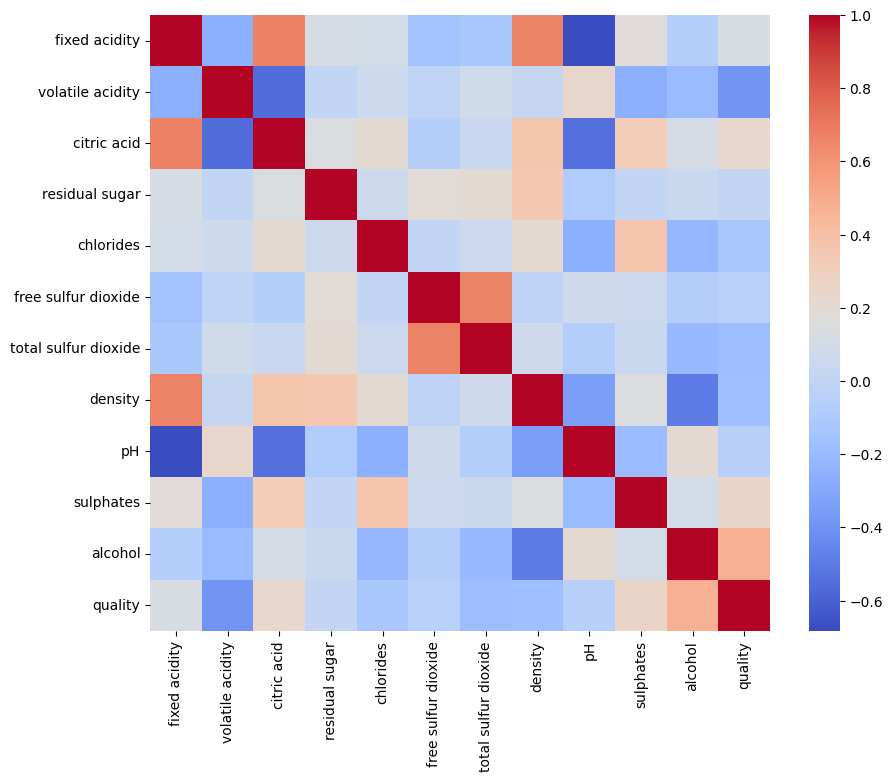

In [144]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm",)
plt.show()

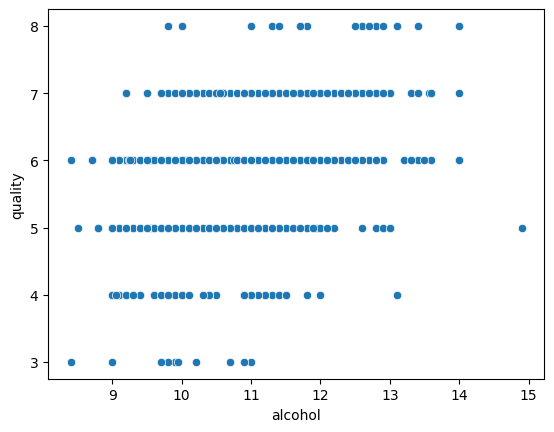

In [145]:
sns.scatterplot(x="alcohol", y = "quality", data=df)
plt.show()

In [146]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=42)

In [147]:
x_train = train[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]
y_train = train['quality']

In [148]:
x_test = test[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]
y_test = test['quality']

In [149]:


# GradientBoosting con parámetros optimizados para este dataset
model = GradientBoostingRegressor(
    n_estimators=200,   
    learning_rate=0.1,
    max_depth=5,                
    random_state=42
)
model.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [150]:
y_pred = model.predict(x_test)

In [151]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("MAPE:", mape)
print("MedianAE:", medae)
print("Explained Variance:", evs)

MAE: 0.43694211722515547
MSE: 0.34979998692878905
RMSE: 0.5914389122545024
R2: 0.44828540044501275
MAPE: 0.07999055415843365
MedianAE: 0.30160460210926665
Explained Variance: 0.4493483122396288


In [152]:
from sklearn.metrics import explained_variance_score

evs = explained_variance_score(y_test, y_pred)
print("Explained Variance:", evs)


Explained Variance: 0.4493483122396288


In [153]:
def bias_error(y_true, y_pred):
    return np.mean(y_pred - y_true)

bias = bias_error(y_test, y_pred)
print("Bias:", bias)

Bias: 0.025959795642142743


# Análisis de Métricas de Calidad — Modelo de Regresión (Gradient Boosting) sobre Dataset de Vinos

## Descripción del Dataset

El dataset utilizado corresponde al conjunto de datos de **calidad de vinos tintos** (*Red Wine Quality*),
compuesto por **1,599 registros** y **11 variables fisicoquímicas** como predictores:

- `fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`
- `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, `alcohol`

La variable objetivo es `quality`, con valores enteros en el rango **[3, 8]** y una media de **5.64**.

El modelo utilizado fue **GradientBoostingRegressor** (no lineal), con:
- `n_estimators=200`
- `learning_rate=0.1`
- `max_depth=5`
- `random_state=42`

## Resultados de las Métricas

| Métrica | Valor obtenido |
|---------|---------------|
| **MAE** | 0.4369 |
| **MSE** | 0.3498 |
| **RMSE** | 0.5914 |
| **R²** | 0.4483 |
| **MAPE** | 7.99% |
| **Median Absolute Error** | 0.3016 |
| **Explained Variance** | 0.4493 |
| **Bias** | +0.0260 |

---

## Análisis por Métrica

### MAE — Mean Absolute Error: 0.4369
El MAE indica que, en promedio, la predicción se desvía **0.4369 puntos** de la calidad real.

Para expresar ese error como porcentaje de la **amplitud del rango** de la variable `quality`,
se sigue este procedimiento:

1. Fórmula del MAE:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

2. Cálculo de la amplitud del rango de `quality`:

$$
\text{Amplitud} = y_{\max} - y_{\min} = 8 - 3 = 5
$$

3. Conversión del MAE a porcentaje de la amplitud:

$$
\%\,\text{error sobre amplitud} = \frac{MAE}{\text{Amplitud}} \times 100
$$

4. Sustitución numérica:

$$
\frac{0.4369}{5} \times 100 = 8.738\% \approx 8.7\%
$$

Por eso se afirma que el error promedio equivale aproximadamente al **8.7% de la amplitud del rango**.

Nota: si en lugar de amplitud (5 puntos) se usan los **6 niveles posibles** (3, 4, 5, 6, 7, 8),
el valor sería:

$$
\frac{0.4369}{6} \times 100 = 7.28\% \approx 7.3\%
$$

### MSE — Mean Squared Error: 0.3498
Al elevar los errores al cuadrado, los casos en los que el modelo falla por 1 o más puntos
pesan más que los errores pequeños. Un valor de 0.35 indica que, aunque la mayoría de los
errores son pequeños, existen predicciones con desviaciones considerables.

### RMSE — Root Mean Squared Error: 0.5914
El error típico del modelo es de **~0.59 puntos** en la escala de calidad.
El RMSE es mayor que el MAE (0.44), lo que confirma la presencia de algunas
predicciones con errores grandes que el MSE amplifica.

### R² — Coeficiente de Determinación: 0.4483
El modelo explica el **44.8% de la variabilidad** en la calidad del vino.
Esto indica un desempeño moderado: el modelo captura parte importante de la señal,
pero todavía queda variabilidad no explicada por las variables disponibles.

### MAPE — Mean Absolute Percentage Error: 7.99%
El error promedio porcentual es de aproximadamente **8%**.
Esta métrica es correcta como referencia general, pero en una variable discreta y acotada
como `quality`, suele ser más interpretable priorizar MAE y RMSE.

### Median Absolute Error: 0.3016
La mediana de los errores absolutos es **0.30 puntos**, menor que el MAE (0.44).
Esto indica que la **mayoría de las predicciones** son bastante precisas,
pero algunos casos extremos elevan el promedio. Esta métrica es más robusta
frente a valores atípicos que el MAE.

### Explained Variance: 0.4493
Muy cercana al R² (0.4483), lo que sugiere coherencia entre ambas medidas
de varianza explicada en el conjunto de prueba.

### Bias: +0.0260
El modelo presenta un **sesgo positivo muy leve** (+0.026), lo que significa que
en promedio sobreestima la calidad del vino en apenas **0.026 puntos**.
Este valor es prácticamente cero, indicando que el modelo está bien calibrado
en dirección (sin sesgo sistemático relevante).

---

## Conclusión

El modelo de regresión **Gradient Boosting** aplicado sobre el dataset de calidad de vinos
ofrece un desempeño **moderado**:

- El **error promedio es manejable** (~0.44 puntos en una escala de 3 a 8)
- El **R² de 0.45** indica que el modelo captura cerca de la mitad de la variabilidad
- El **Bias cercano a cero** es un punto positivo: no hay sesgo sistemático importante
- La diferencia entre MAE (0.44) y Median AE (0.30) sugiere la presencia de
  **algunos casos extremos** que aumentan el error promedio

Como mejora metodológica, conviene complementar este resultado con validación cruzada
para estimar mejor la estabilidad de las métricas frente a distintas particiones de datos.